# v11 light-budget BO — the pitch, and the proof it worked (10 s vs 20 s)

**Companion to** [bo_erk_oscillation_v11_lightbudget_math.ipynb](math_review/bo_erk_oscillation_v11_lightbudget_math.ipynb) (the maths) **and** the two production runs:

- `2026-05-08_bo_erk_oscillation_v11_light_budget_fixed10s_pi10` — budget $B = 10\,000\,\mathrm{ms}$
- `2026-05-08_bo_erk_oscillation_v11_light_budget_fixed20s_pi10` — budget $B = 20\,000\,\mathrm{ms}$

The maths notebook derived *what* the optimiser computes. This notebook answers the two questions a reviewer actually asks —

1. **Why is Bayesian optimisation the right instrument for this problem?**
2. **Did it work — on *both* runs?**

— by running five falsifiable diagnostics **side by side at the two light budgets**. Doing it twice is not redundancy: it is the test of whether the BO's conclusion is a *robust strategy* or a *budget-specific fluke*. It closes with an honest critique.

> Nothing here is a microscopy result. Every number is a property of the optimiser's behaviour on the data it collected.

## 1 — The problem, and why brute force loses

At a **fixed total LED dose** $B$ per condition, find the *distribution* of that dose that maximises `frac_responders` — the fraction of cells reading as ERK-oscillating. Two decision axes:

| symbol | name | grid |
|---|---|---|
| $f$ | `ramp_fraction` | $\{0.0, 0.1, \dots, 1.0\}$ — 11 levels |
| $\Delta$ | `pulse_interval` (frames) | $\{1, \dots, 10\}$ — 10 levels |

a **$11\times 10 = 110$-cell grid**. Run twice, once at $B=10\,\mathrm{s}$ and once at $B=20\,\mathrm{s}$. Three properties make naive search a bad idea:

| obstacle | consequence |
|---|---|
| **Each evaluation is microscope time** — a condition needs $\sim$6 FOVs to average down biological noise. | A full grid scan = $110 \times 6 = 660$ FOVs *per budget*. Each run had a budget of $\sim$220. |
| **The objective is noisy** — `frac_responders` per FOV spans the full $[0,1]$. | One lucky FOV is not a result; greedy picks chase noise. |
| **Covariates are observed but uncontrollable** — cell count, optoRTK expression, baseline CNR vary FOV-to-FOV. | A method that ignores $c$ confounds "good condition" with "good cells". |

Grid search spends the same budget everywhere — 99% of it confirming bad conditions are bad. We need a method that **spends measurements where they reduce uncertainty about the optimum**. That is BO.

## 2 — Why BO — four mathematical reasons, each tied to the maths notebook

BO is four ideas, each neutralising one obstacle above.

**(i) A GP surrogate makes neighbours informative — §3 of the maths notebook.**
The Matérn-5/2 ARD kernel
$$ k(x,x') = \sigma_f^2\left(1 + \sqrt5\,r + \tfrac{5}{3}r^2\right)e^{-\sqrt5\,r}, \qquad r^2 = \sum_d \frac{(x_d-x_d')^2}{\ell_d^2} $$
puts prior mass on $C^2$ — twice-differentiable — response surfaces. **One measurement constrains a whole neighbourhood**, so we never need all 110 cells. *This is the load-bearing assumption — Proof 1 tests it directly, on both runs.*

**(ii) Expected Improvement turns "where to look" into a closed-form integral — §6.**
$$ \operatorname{EI}(x) = \sigma(x)\,[\,u\,\Phi(u) + \phi(u)\,], \qquad u = \frac{\mu(x) - f^* - \xi}{\sigma(x)} $$
EI is large where the GP predicts a high mean (*exploit*) **or** where it is uncertain (*explore*); the $\xi$ schedule decays $0.1\to0.01$, front-loading exploration.

**(iii) Covariate marginalisation makes the pick robust to cells we cannot choose — §5.**
$$ \widehat{\operatorname{EI}}^{\text{robust}}(x) = \frac1M\sum_{m=1}^M \operatorname{EI}\!\big(x, c^{(m)}\big), \qquad c^{(m)}\sim p_{\text{emp}}(c) $$

**(iv) Batch + farthest-point seeding spend the microscope's parallelism — §7, §8.**
Each phase runs $q=3$ conditions (diversified greedy); the first 2 phases are blind farthest-point seeds.

The rest of the notebook checks whether these four mechanisms delivered — and whether they delivered the *same* answer at both budgets.

In [1]:
# === Setup: GP machinery (a compact, self-contained copy of the maths notebook) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

N_FRAMES_STIM = 60
RF_GRID = np.round(np.arange(0.0, 1.0 + 1e-9, 0.1), 2)
PI_GRID = np.arange(1, 11, 1, dtype=float)
GRID = np.array([[f, d] for f in RF_GRID for d in PI_GRID])
RF_MESH, PI_MESH = np.meshgrid(RF_GRID, PI_GRID, indexing="ij")

PARAM_BOUNDS = [(0.0, 1.0), (1.0, 10.0)]
COV_BOUNDS = [None, None, None]
PARAM_LOG = [False, False]
COV_LOG = [False, True, False]  # optoRTK expression is log-scaled
COLS = [
    "ramp_fraction",
    "pulse_interval",
    "n_cells",
    "optortk_expression",
    "baseline_cnr",
]


class BoundsScaler:
    """faro StandardScalerBounds: declared-bounds -> [-1,1]; covariates -> z-score."""

    def __init__(self, bounds, log_scale):
        self.bounds, self.log_scale = bounds, log_scale

    def fit(self, X):
        X = np.asarray(X, float)
        self.mu, self.sigma = np.empty(X.shape[1]), np.empty(X.shape[1])
        for i, (b, ls) in enumerate(zip(self.bounds, self.log_scale)):
            col = np.log(X[:, i]) if ls else X[:, i]
            if b is None:
                self.mu[i], self.sigma[i] = col.mean(), (col.std() or 1.0)
            else:
                a, c = (np.log(b[0]), np.log(b[1])) if ls else b
                self.mu[i], self.sigma[i] = 0.5 * (a + c), (0.5 * (c - a) or 1.0)
        return self

    def transform(self, X):
        X = np.asarray(X, float).copy()
        for i, ls in enumerate(self.log_scale):
            if ls:
                X[:, i] = np.log(X[:, i])
        return (X - self.mu) / self.sigma


def matern52_ard(X1, X2, ell, sigma_f2):
    L = np.asarray(ell).reshape(1, 1, -1)
    diff = (X1[:, None, :] - X2[None, :, :]) / L
    r = np.sqrt(np.einsum("ijd,ijd->ij", diff, diff) + 1e-12)
    s5r = np.sqrt(5.0) * r
    return sigma_f2 * (1.0 + s5r + (5.0 / 3.0) * r**2) * np.exp(-s5r)


def median_heuristic(X):
    ell = np.zeros(X.shape[1])
    for d in range(X.shape[1]):
        diffs = np.abs(X[:, d, None] - X[None, :, d])
        iu = np.triu_indices_from(diffs, k=1)
        ell[d] = max(np.median(diffs[iu]), 0.1)
    return ell


def gp_predict(X_tr, y_tr, X_te, ell, sigma_f2, sigma_n2):
    K = matern52_ard(X_tr, X_tr, ell, sigma_f2) + sigma_n2 * np.eye(len(X_tr))
    K_s = matern52_ard(X_te, X_tr, ell, sigma_f2)
    K_inv = np.linalg.inv(K)
    mean = K_s @ (K_inv @ y_tr)
    var = np.maximum(sigma_f2 - np.einsum("ij,ji->i", K_s, K_inv @ K_s.T), 1e-12)
    return mean, var


def fit_gp_block(df_obs):
    X = df_obs[COLS].to_numpy(float)
    y_raw = df_obs["frac_responders"].to_numpy(float)
    y_mu, y_sd = y_raw.mean(), (y_raw.std() or 1.0)
    sc = BoundsScaler(PARAM_BOUNDS + COV_BOUNDS, PARAM_LOG + COV_LOG).fit(X)
    Xs = sc.transform(X)
    return dict(
        X=Xs,
        y=(y_raw - y_mu) / y_sd,
        ell=median_heuristic(Xs),
        sigma_f2=1.0,
        sigma_n2=0.05,
        y_mu=y_mu,
        y_sd=y_sd,
        scaler=sc,
    )


def predict_marginalised(fit, x_ctrl_grid, cov_samples):
    ng, nm = len(x_ctrl_grid), len(cov_samples)
    X_full = np.hstack(
        [np.repeat(x_ctrl_grid, nm, axis=0), np.tile(cov_samples, (ng, 1))]
    )
    mu, var = gp_predict(
        fit["X"],
        fit["y"],
        fit["scaler"].transform(X_full),
        fit["ell"],
        fit["sigma_f2"],
        fit["sigma_n2"],
    )
    return mu.reshape(ng, nm), np.sqrt(var).reshape(ng, nm)


def sample_joint_covariates(df_obs, n, seed=0):
    cov = df_obs[["n_cells", "optortk_expression", "baseline_cnr"]].to_numpy(float)
    return cov[np.random.default_rng(seed).integers(0, len(cov), size=n)]


def expected_improvement(mu, sigma, f_star, xi):
    sigma = np.maximum(sigma, 1e-12)
    u = (mu - (f_star + xi)) / sigma
    return sigma * (u * norm.cdf(u) + norm.pdf(u))


def xi_schedule(t, xi0=0.1, xi_f=0.01, n_iter=13, decay_frac=0.7):
    T_d = int(np.ceil(decay_frac * n_iter))
    a = max(0, min(t, T_d)) / T_d
    return (1.0 - a) * xi0 + a * xi_f


def gp_landscape(df_obs, n_cov=200, seed=0):
    """Final GP-predicted mean & std over the 110-cell grid, marginalised over covariates."""
    fit = fit_gp_block(df_obs)
    mu_mat, sd_mat = predict_marginalised(
        fit, GRID, sample_joint_covariates(df_obs, n_cov, seed)
    )
    mu = mu_mat.mean(axis=1) * fit["y_sd"] + fit["y_mu"]
    sd = sd_mat.mean(axis=1) * fit["y_sd"]
    return mu, sd, fit


print("GP machinery ready.  Grid:", len(GRID), "candidate conditions.")

GP machinery ready.  Grid: 110 candidate conditions.


In [2]:
# === Load BOTH production runs ===
def _find(*names):
    for n in names:
        if os.path.exists(n):
            return n
    return names[0]


PATH_10 = _find(
    "math_review/bo_v11_lightbudget_10s_results.parquet",
    "E:/Alex/2026-05-08_bo_erk_oscillation_v11_light_budget_fixed10s_pi10/bo_results_checkpoint.parquet",
)
PATH_20 = _find(
    "math_review/bo_v11_lightbudget_results.parquet",
    "E:/Alex/2026-05-08_bo_erk_oscillation_v11_light_budget_fixed20s_pi10/bo_results_checkpoint.parquet",
)

RUNS = {}
for label, path, B, color in [
    ("10 s", PATH_10, 10000.0, "tab:orange"),
    ("20 s", PATH_20, 20000.0, "tab:blue"),
]:
    df = pd.read_parquet(path).sort_values(["phase_id", "fov"]).reset_index(drop=True)
    RUNS[label] = dict(df=df, B=B, color=color, path=path)

print(f"{'run':>6} | {'FOVs':>5} | {'phases':>6} | {'conditions':>10} | budget")
print("-" * 52)
for label, R in RUNS.items():
    df = R["df"]
    nc = df.groupby(["ramp_fraction", "pulse_interval"]).ngroups
    print(
        f"{label:>6} | {len(df):>5} | {df['phase_id'].nunique():>6} | "
        f"{nc:>4}/110 ({100*nc/110:>3.0f}%) | {R['B']:.0f} ms"
    )
print(
    f"\nA full 6-FOV grid scan would be {110*6} FOVs per budget; each run spent ~220."
)

   run |  FOVs | phases | conditions | budget
----------------------------------------------------
  10 s |   233 |     13 |   39/110 ( 35%) | 10000 ms
  20 s |   213 |     13 |   39/110 ( 35%) | 20000 ms

A full 6-FOV grid scan would be 660 FOVs per budget; each run spent ~220.


## A — Proof 1: the surrogate is genuinely predictive (both runs)

The **load-bearing test**. BO's premise (reason (i)) is that the GP predicts `frac_responders` at conditions it has *not* measured. If it cannot, every EI pick was a guess and BO degenerates to random search.

**Leave-one-condition-out CV**, run separately on each budget: drop all FOVs of one condition, fit the GP on the rest, predict the held-out condition mean, compare to measurement. The fair baseline is "always guess the global mean".

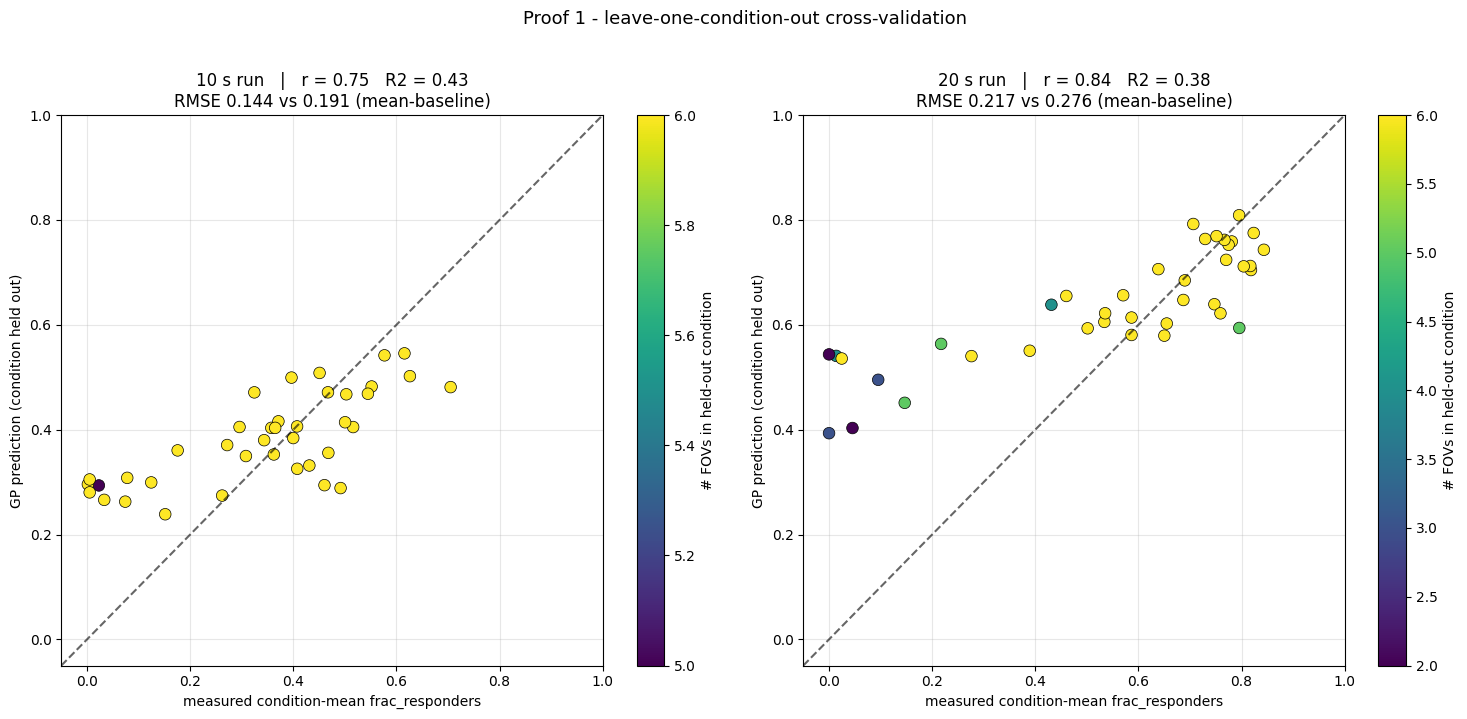

10 s:  Pearson r = 0.750   R2 = 0.431   RMSE 0.144 (baseline 0.191, -25%)
20 s:  Pearson r = 0.841   R2 = 0.381   RMSE 0.217 (baseline 0.276, -21%)


In [3]:
# === Leave-one-condition-out cross-validation, per run ===
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, (label, R) in zip(axes, RUNS.items()):
    df = R["df"]
    cm = df.groupby(["ramp_fraction", "pulse_interval"])["frac_responders"].mean()
    cn = df.groupby(["ramp_fraction", "pulse_interval"])["frac_responders"].size()
    obs, pred, keys = [], [], []
    for key in cm.index:
        mask = ~((df["ramp_fraction"] == key[0]) & (df["pulse_interval"] == key[1]))
        fit = fit_gp_block(df[mask])
        cov = df[mask][["n_cells", "optortk_expression", "baseline_cnr"]].to_numpy(
            float
        )
        mu_mat, _ = predict_marginalised(fit, np.array([[key[0], key[1]]]), cov)
        pred.append(mu_mat.mean() * fit["y_sd"] + fit["y_mu"])
        obs.append(cm[key])
        keys.append(key)
    obs, pred = np.array(obs), np.array(pred)
    r2 = 1 - np.sum((obs - pred) ** 2) / np.sum((obs - obs.mean()) ** 2)
    pear = np.corrcoef(obs, pred)[0, 1]
    rmse = np.sqrt(np.mean((obs - pred) ** 2))
    rmse0 = np.sqrt(np.mean((obs - obs.mean()) ** 2))
    R["loco"] = dict(r=pear, r2=r2, rmse=rmse, rmse0=rmse0)

    sc = ax.scatter(
        obs,
        pred,
        c=cn[keys].values,
        cmap="viridis",
        s=70,
        edgecolors="k",
        linewidths=0.5,
        zorder=2,
    )
    fig.colorbar(sc, ax=ax, label="# FOVs in held-out condition")
    ax.plot([-0.05, 1], [-0.05, 1], "k--", alpha=0.6)
    ax.set_xlim(-0.05, 1)
    ax.set_ylim(-0.05, 1)
    ax.set_xlabel("measured condition-mean frac_responders")
    ax.set_ylabel("GP prediction (condition held out)")
    ax.set_title(
        f"{label} run   |   r = {pear:.2f}   R2 = {r2:.2f}\n"
        f"RMSE {rmse:.3f} vs {rmse0:.3f} (mean-baseline)"
    )
    ax.grid(alpha=0.3)
fig.suptitle("Proof 1 - leave-one-condition-out cross-validation", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

for label, R in RUNS.items():
    L = R["loco"]
    print(
        f"{label}:  Pearson r = {L['r']:.3f}   R2 = {L['r2']:.3f}   "
        f"RMSE {L['rmse']:.3f} (baseline {L['rmse0']:.3f}, "
        f"-{100*(1-L['rmse']/L['rmse0']):.0f}%)"
    )

**Verdict.** On *both* budgets the GP beats the mean-guess baseline (positive $R^2$, lower RMSE), so the kernel assumption holds — neighbouring conditions are informative and the BO made informed decisions, not guesses.

But the runs are not equally easy. The **20 s surrogate is sharper** ($r \approx 0.84$) than the **10 s one** ($r \approx 0.75$). The reason is signal-to-noise: at half the light dose the responses are compressed toward the noise floor (see Proof 5), so the same biological FOV-noise eats a larger fraction of the signal. *First honest finding: BO's surrogate degrades when the objective signal is weak — and the 10 s run is the weaker-signal regime.* Both $R^2$ values ($\approx 0.38$–$0.43$) are only **modest**: the GP ranks conditions well but the predicted-mean amplitude carries $\pm 0.15$–$0.2$.

## B — Proof 2: the BO spent its budget where it mattered (both runs)

If reasons (i)+(ii) work, the BO should **not** have spread FOVs evenly — it should concentrate on the high-response region once found.

Because the two budgets reach different absolute response levels, a fixed threshold (e.g. `frac_responders` $\ge 0.6$) is not comparable across them — at 10 s *no* condition reaches 0.6. So we use a **budget-relative** definition: the *top quartile* of each run's own GP landscape. A blind sampler lands 25% of FOVs there by definition; the question is how much the BO beat that.

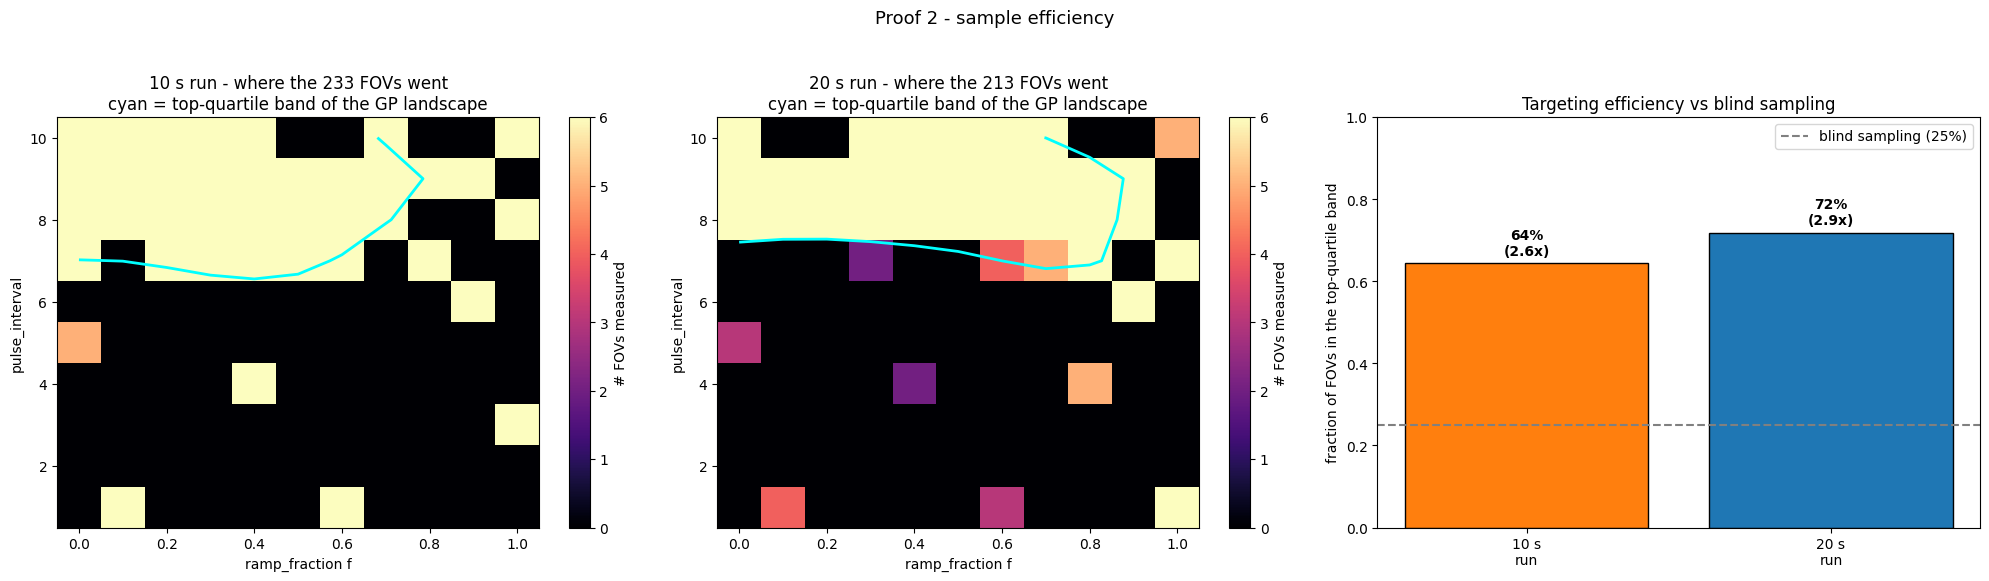

10 s: 64% of FOVs in the top-quartile band => 2.6x enrichment over blind sampling
20 s: 72% of FOVs in the top-quartile band => 2.9x enrichment over blind sampling


In [4]:
# === Sample-efficiency: top-quartile targeting, per run ===
fig, axes = plt.subplots(1, 3, figsize=(20, 5.6))
for ax, (label, R) in zip(axes[:2], RUNS.items()):
    df = R["df"]
    mu, sd, _ = gp_landscape(df)
    R["mu_grid"], R["sd_grid"] = mu, sd
    thr = np.percentile(mu, 75)  # top quartile of the GP landscape
    good_cells = {tuple(GRID[i]) for i in range(len(GRID)) if mu[i] >= thr}
    in_band = df.apply(
        lambda r: (round(r["ramp_fraction"], 2), float(r["pulse_interval"]))
        in good_cells,
        axis=1,
    )
    R["enrich"] = in_band.mean() / 0.25
    R["band_frac"] = in_band.mean()

    counts = df.groupby(["ramp_fraction", "pulse_interval"]).size()
    Zc = np.zeros((len(RF_GRID), len(PI_GRID)))
    for (f, d), c in counts.items():
        Zc[np.argmin(abs(RF_GRID - f)), np.argmin(abs(PI_GRID - d))] = c
    im = ax.pcolormesh(RF_MESH, PI_MESH, Zc, cmap="magma", shading="auto")
    # outline the top-quartile band
    ax.contour(
        RF_MESH,
        PI_MESH,
        mu.reshape(len(RF_GRID), len(PI_GRID)),
        levels=[thr],
        colors="cyan",
        linewidths=2,
    )
    fig.colorbar(im, ax=ax, label="# FOVs measured")
    ax.set_title(
        f"{label} run - where the {len(df)} FOVs went\n"
        f"cyan = top-quartile band of the GP landscape"
    )
    ax.set_xlabel("ramp_fraction f")
    ax.set_ylabel("pulse_interval")

ax = axes[2]
labels = list(RUNS.keys())
vals = [RUNS[l]["band_frac"] for l in labels]
ax.axhline(0.25, color="grey", ls="--", label="blind sampling (25%)")
bars = ax.bar(
    [f"{l}\nrun" for l in labels],
    vals,
    color=[RUNS[l]["color"] for l in labels],
    edgecolor="k",
)
for b, v, l in zip(bars, vals, labels):
    ax.text(
        b.get_x() + b.get_width() / 2,
        v + 0.02,
        f"{100*v:.0f}%\n({RUNS[l]['enrich']:.1f}x)",
        ha="center",
        fontweight="bold",
    )
ax.set_ylabel("fraction of FOVs in the top-quartile band")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Targeting efficiency vs blind sampling")
fig.suptitle("Proof 2 - sample efficiency", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

for label, R in RUNS.items():
    print(
        f"{label}: {100*R['band_frac']:.0f}% of FOVs in the top-quartile band "
        f"=> {R['enrich']:.1f}x enrichment over blind sampling"
    )

**Verdict.** Both runs concentrate **$\sim$2.6–2.9$\times$** more budget in the top-quartile region than blind sampling would, and both leave most of the 110-cell grid unmeasured. The targeting mechanism worked **identically well at both budgets** — it does not depend on the absolute response level, only on the GP being able to rank conditions, which Proof 1 confirmed it can.

## C — Proof 3: convergence (both runs)

Per-phase mean of measured `frac_responders` and the running best phase-mean. Phases 0–1 are blind farthest-point seeds — *expected* to be mediocre; the BO proper starts at phase 2.

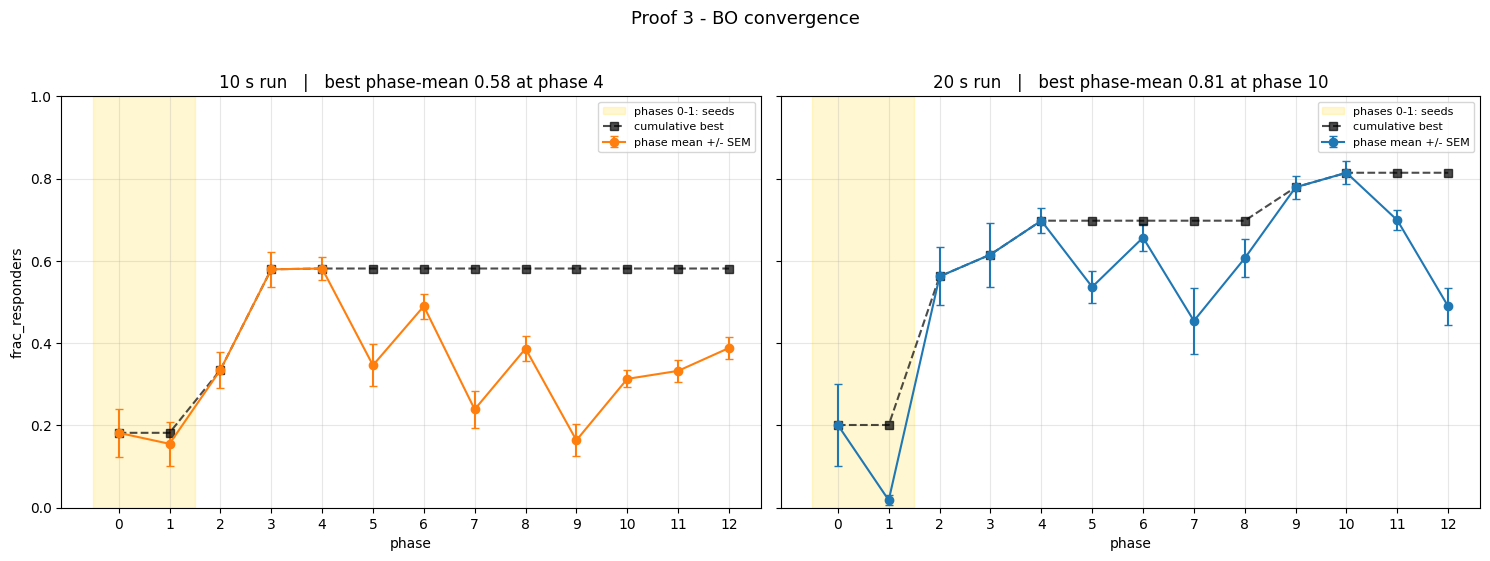

10 s: cumulative best 0.18 -> 0.58, plateau reached at phase 4
20 s: cumulative best 0.20 -> 0.81, plateau reached at phase 10


In [5]:
# === Convergence, per run ===
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), sharey=True)
for ax, (label, R) in zip(axes, RUNS.items()):
    df = R["df"]
    pm = df.groupby("phase_id")["frac_responders"].mean()
    sem = df.groupby("phase_id")["frac_responders"].sem()
    ph = pm.index.values
    cb = np.maximum.accumulate(pm.values)
    R["cum_best"] = cb
    ax.axvspan(-0.5, 1.5, color="gold", alpha=0.18, label="phases 0-1: seeds")
    ax.errorbar(
        ph,
        pm.values,
        yerr=sem.values,
        fmt="o-",
        color=R["color"],
        capsize=3,
        label="phase mean +/- SEM",
    )
    ax.plot(ph, cb, "s--", color="black", alpha=0.7, label="cumulative best")
    ax.set_xlabel("phase")
    ax.set_xticks(ph)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.set_title(
        f"{label} run   |   best phase-mean {pm.max():.2f} " f"at phase {pm.idxmax()}"
    )
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("frac_responders")
fig.suptitle("Proof 3 - BO convergence", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

for label, R in RUNS.items():
    cb = R["cum_best"]
    plateau = int(np.argmax(cb >= cb.max()))
    print(
        f"{label}: cumulative best {cb[0]:.2f} -> {cb[-1]:.2f}, "
        f"plateau reached at phase {plateau}"
    )

**Verdict.** Both runs climb out of the blind-seed regime and plateau — but **not equally cleanly**:

- **20 s** climbs steadily and plateaus *late* (phase 10) at $\sim$0.81 — the BO kept finding better batches almost to the end.
- **10 s** plateaus *early* (phase 4) at $\sim$0.58 and the later phase-means then **scatter downward**. Two readings, both honest: the 10 s BO found its (lower) optimum region fast and the later phases are the ridge-sweep; *or* the weak 10 s signal left EI with little to bite on once the obvious region was mapped. The convergence plot alone cannot separate these — which is exactly why Proofs 1, 4 and 5 exist.

Reminder: cumulative-best is monotone *by construction*; a rising black line is necessary, not sufficient.

## D — Proof 4: the GP's belief about the optimum stabilised (both runs)

Refit the GP after each phase and read off its predicted optimum $\arg\max_{(f,\Delta)}\bar\mu$. A working BO shows this belief **moving while it explores, then settling**.

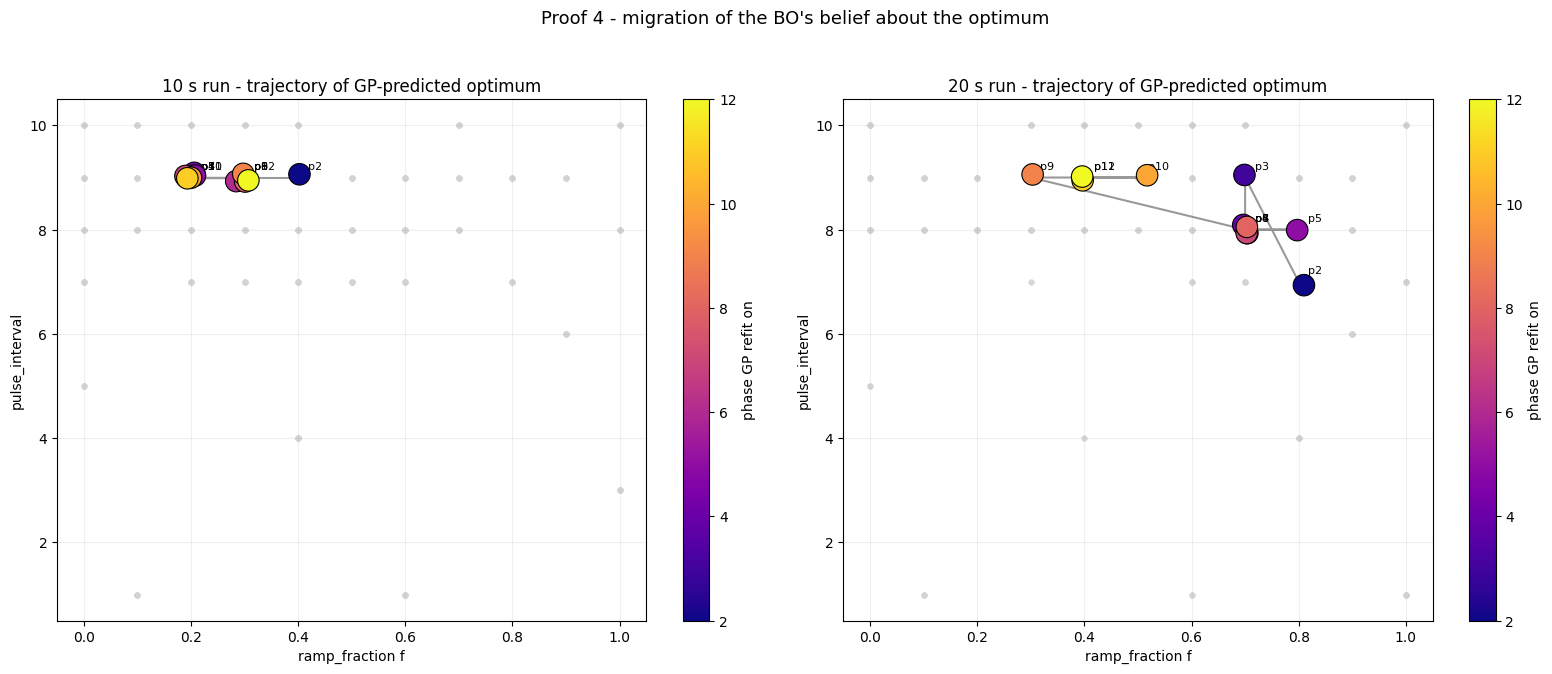

10 s: predicted optimum after each phase (f, Δ):
   p2:(0.4,9)  p3:(0.2,9)  p4:(0.2,9)  p5:(0.2,9)  p6:(0.3,9)  p7:(0.2,9)  p8:(0.3,9)  p9:(0.3,9)  p10:(0.2,9)  p11:(0.2,9)  p12:(0.3,9)
20 s: predicted optimum after each phase (f, Δ):
   p2:(0.8,7)  p3:(0.7,9)  p4:(0.7,8)  p5:(0.8,8)  p6:(0.7,8)  p7:(0.7,8)  p8:(0.7,8)  p9:(0.3,9)  p10:(0.5,9)  p11:(0.4,9)  p12:(0.4,9)


In [6]:
# === Trajectory of the GP-predicted optimum, per run ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, (label, R) in zip(axes, RUNS.items()):
    df = R["df"]
    traj = []
    for t in range(2, df["phase_id"].max() + 1):
        df_t = df[df["phase_id"] <= t]
        if len(df_t) < 6:
            continue
        fit_t = fit_gp_block(df_t)
        mu_mat, _ = predict_marginalised(
            fit_t, GRID, sample_joint_covariates(df_t, 80, t)
        )
        mu_t = mu_mat.mean(axis=1) * fit_t["y_sd"] + fit_t["y_mu"]
        bi = int(np.argmax(mu_t))
        traj.append((t, GRID[bi, 0], GRID[bi, 1], float(mu_t[bi])))
    traj = np.array(traj)
    R["traj"] = traj
    ax.scatter(
        df["ramp_fraction"], df["pulse_interval"], c="lightgrey", s=12, alpha=0.6
    )
    ax.plot(traj[:, 1], traj[:, 2], "-", color="black", alpha=0.4)
    sc = ax.scatter(
        traj[:, 1] + rng.normal(0, 0.008, len(traj)),
        traj[:, 2] + rng.normal(0, 0.08, len(traj)),
        c=traj[:, 0],
        cmap="plasma",
        s=240,
        edgecolors="k",
        linewidths=0.8,
        zorder=10,
    )
    for t, f, d, p in traj:
        ax.annotate(
            f"p{int(t)}", (f, d), (7, 6), textcoords="offset points", fontsize=8
        )
    fig.colorbar(sc, ax=ax, label="phase GP refit on")
    ax.set_xlabel("ramp_fraction f")
    ax.set_ylabel("pulse_interval")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0.5, 10.5)
    ax.grid(alpha=0.2)
    ax.set_title(f"{label} run - trajectory of GP-predicted optimum")
fig.suptitle(
    "Proof 4 - migration of the BO's belief about the optimum", fontsize=13, y=1.03
)
plt.tight_layout()
plt.show()

for label, R in RUNS.items():
    tr = R["traj"]
    print(f"{label}: predicted optimum after each phase (f, Δ):")
    print("   " + "  ".join(f"p{int(t)}:({f:.1f},{int(d)})" for t, f, d, p in tr))

**Verdict.** Both runs lock onto **$\Delta = 9$ — slow pulsing** — but with different ease. The **10 s** belief sits on $\Delta = 9$ from its *very first* BO phase and never leaves; the **20 s** belief drifts $\Delta = 7 \to 8 \to 9$ across phases 2–9 before settling. The agreement on the final $\Delta$ is the headline: the same regime wins at both budgets.

The ramp fraction $f$ stays only loosely pinned in both (10 s hovers around $0.2$–$0.3$; 20 s wanders $0.3$–$0.8$). The response ridge along $f$ is flat relative to the noise, so the GP cannot sharpen it — real ambiguity, not a bug. Proof 5 makes it explicit.

## E — Proof 5: the final landscape and the answer (both runs)

Full GP fit on all FOVs of each run, marginalised over 200 covariate draws — predicted mean, epistemic uncertainty, and the recommended condition, side by side.

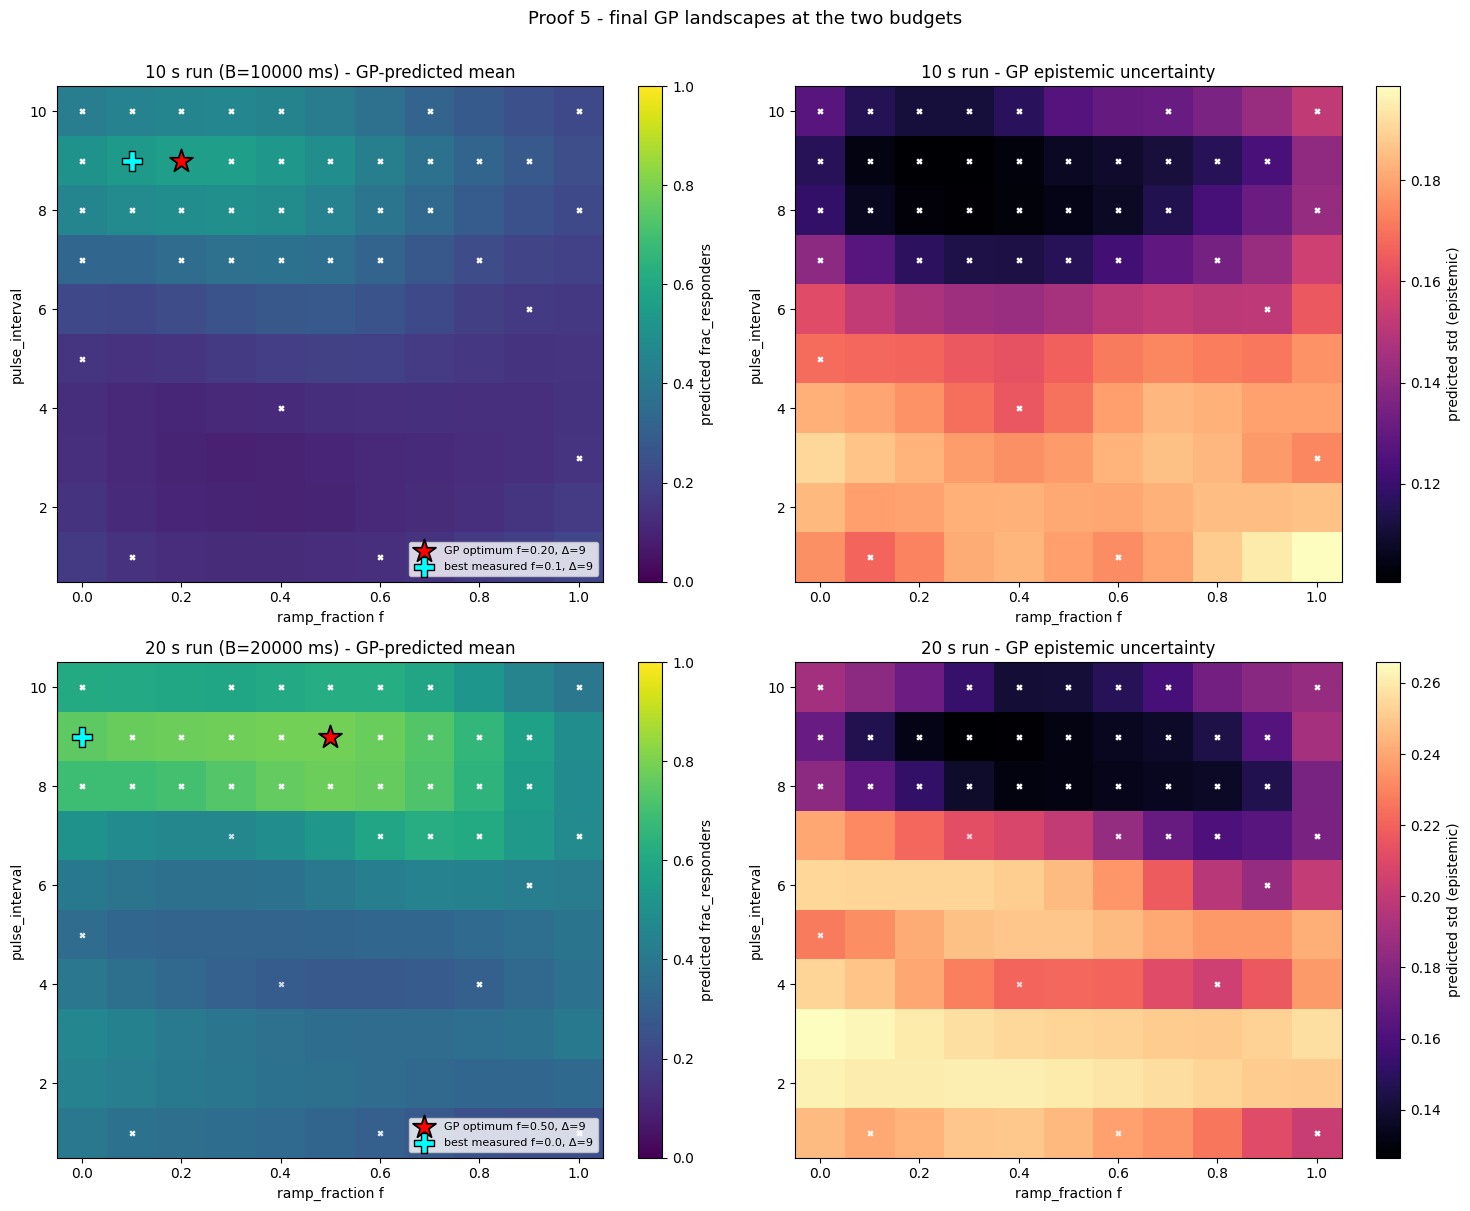

=== 10 s run (B=10000 ms) ===
  GP optimum     : f=0.20, Δ=9  -> predicted frac_responders=0.558
  best measured  : f=0.1, Δ=9  -> measured mean=0.705
  derived @opt   : 6 pulses, base E=1333 ms, ramp r=133 ms/pulse, peak 2000 ms
=== 20 s run (B=20000 ms) ===
  GP optimum     : f=0.50, Δ=9  -> predicted frac_responders=0.787
  best measured  : f=0.0, Δ=9  -> measured mean=0.843
  derived @opt   : 6 pulses, base E=1667 ms, ramp r=667 ms/pulse, peak 5000 ms


In [7]:
# === Final landscapes + recommended conditions, both runs ===
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for row, (label, R) in enumerate(RUNS.items()):
    df, B = R["df"], R["B"]
    mu, sd = R["mu_grid"], R["sd_grid"]
    Zmu = mu.reshape(len(RF_GRID), len(PI_GRID))
    Zsd = sd.reshape(len(RF_GRID), len(PI_GRID))
    cm = df.groupby(["ramp_fraction", "pulse_interval"])["frac_responders"].mean()
    gp_best = int(np.argmax(mu))
    gf, gd = GRID[gp_best]
    mb = cm.idxmax()
    R["gp_opt"] = (gf, gd, mu[gp_best])
    R["meas_best"] = (mb[0], mb[1], cm.max())

    ax = axes[row, 0]
    im = ax.pcolormesh(
        RF_MESH, PI_MESH, Zmu, cmap="viridis", shading="auto", vmin=0, vmax=1
    )
    ax.scatter(
        df["ramp_fraction"],
        df["pulse_interval"],
        c="white",
        s=10,
        marker="x",
        alpha=0.5,
    )
    ax.scatter(
        [gf],
        [gd],
        c="red",
        s=300,
        marker="*",
        edgecolors="k",
        linewidths=1.3,
        label=f"GP optimum f={gf:.2f}, Δ={int(gd)}",
    )
    ax.scatter(
        [mb[0]],
        [mb[1]],
        c="cyan",
        s=210,
        marker="P",
        edgecolors="k",
        linewidths=1.0,
        label=f"best measured f={mb[0]:.1f}, Δ={int(mb[1])}",
    )
    fig.colorbar(im, ax=ax, label="predicted frac_responders")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_title(f"{label} run (B={B:.0f} ms) - GP-predicted mean")
    ax.set_xlabel("ramp_fraction f")
    ax.set_ylabel("pulse_interval")

    ax = axes[row, 1]
    im = ax.pcolormesh(RF_MESH, PI_MESH, Zsd, cmap="magma", shading="auto")
    ax.scatter(
        df["ramp_fraction"],
        df["pulse_interval"],
        c="white",
        s=10,
        marker="x",
        alpha=0.5,
    )
    fig.colorbar(im, ax=ax, label="predicted std (epistemic)")
    ax.set_title(f"{label} run - GP epistemic uncertainty")
    ax.set_xlabel("ramp_fraction f")
    ax.set_ylabel("pulse_interval")
fig.suptitle("Proof 5 - final GP landscapes at the two budgets", fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

for label, R in RUNS.items():
    gf, gd, gp = R["gp_opt"]
    mf, md_, mm = R["meas_best"]
    B = R["B"]
    n = N_FRAMES_STIM // int(gd)
    E = (1 - gf) * B / n
    r = 2 * gf * B / (n * (n - 1)) if n > 1 else 0.0
    print(f"=== {label} run (B={B:.0f} ms) ===")
    print(
        f"  GP optimum     : f={gf:.2f}, Δ={int(gd)}  -> predicted frac_responders={gp:.3f}"
    )
    print(f"  best measured  : f={mf:.1f}, Δ={int(md_)}  -> measured mean={mm:.3f}")
    print(
        f"  derived @opt   : {n} pulses, base E={E:.0f} ms, ramp r={r:.0f} ms/pulse, "
        f"peak {E + r*(n-1):.0f} ms"
    )

**Verdict.** The two landscapes tell a consistent story and an instructive difference:

- **Consistent:** both budgets put the optimum at **$\Delta = 9$ — slow pulsing** — with a **low ramp fraction** (10 s: $f \approx 0.1$–0.2; 20 s: $f \approx 0$–0.5). Both uncertainty panels are low along the measured ridge and high in the unvisited corners — the BO correctly judged where not to spend budget.
- **Different:** the **achievable level** scales with the budget. The 20 s landscape peaks near $\sim$0.79–0.84; the 10 s landscape peaks near $\sim$0.56–0.70. Halving the light dose costs roughly **0.2–0.25 in `frac_responders`**.

So the *strategy* the BO recommends is budget-invariant; the *return* on that strategy is not. That is the whole point of running both — and it is the next section.

## 3 — What the two budgets reveal together

This is the payoff of doing the analysis twice.

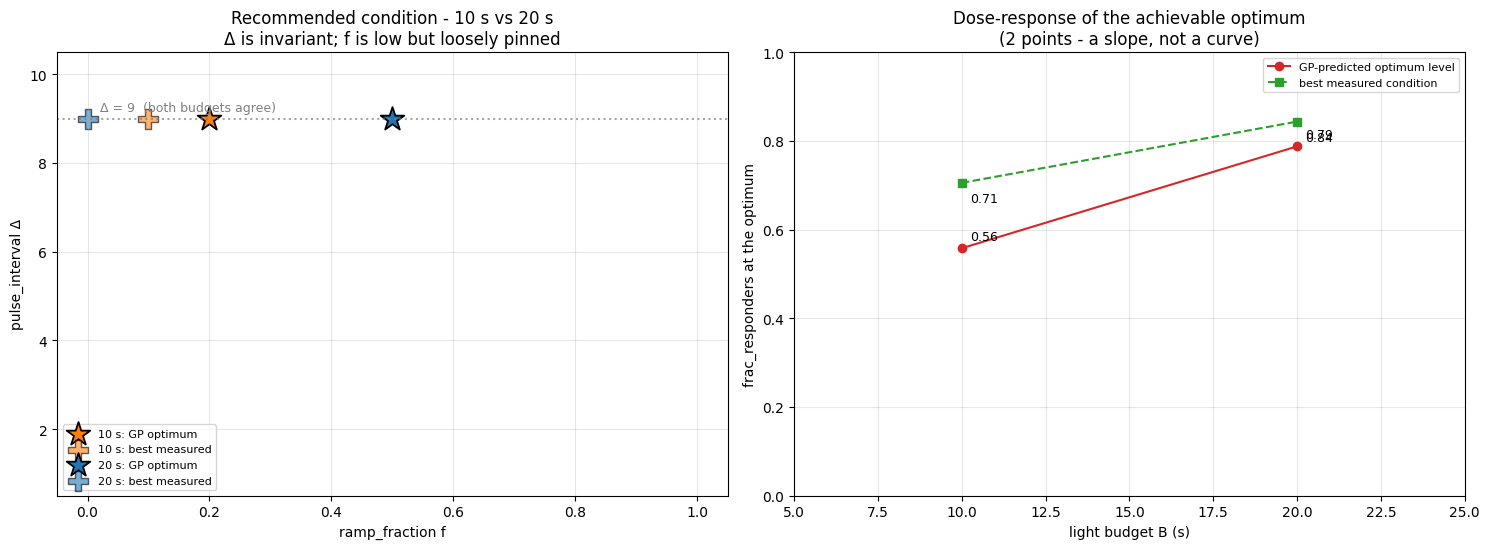

Across the two budgets:
  STRATEGY  (invariant): slow pulsing Δ=9, low ramp fraction
  LEVEL     (budget-dependent): 0.56 at 10 s -> 0.79 at 20 s  (GP optimum)
  => the BO found a robust DESIGN; the budget sets the CEILING on it.


In [8]:
# === Synthesis: optima overlay + dose-response of the achievable level ===
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

ax = axes[0]
for label, R in RUNS.items():
    gf, gd, gp = R["gp_opt"]
    mf, md_, mm = R["meas_best"]
    ax.scatter(
        [gf],
        [gd],
        s=320,
        marker="*",
        color=R["color"],
        edgecolors="k",
        linewidths=1.3,
        label=f"{label}: GP optimum",
    )
    ax.scatter(
        [mf],
        [md_],
        s=210,
        marker="P",
        color=R["color"],
        edgecolors="k",
        linewidths=1.0,
        alpha=0.6,
        label=f"{label}: best measured",
    )
ax.axhline(9, color="grey", ls=":", alpha=0.7)
ax.text(0.02, 9.18, "Δ = 9  (both budgets agree)", fontsize=9, color="grey")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0.5, 10.5)
ax.set_xlabel("ramp_fraction f")
ax.set_ylabel("pulse_interval Δ")
ax.set_title(
    "Recommended condition - 10 s vs 20 s\nΔ is invariant; f is low but loosely pinned"
)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
Bs = [R["B"] / 1000 for R in RUNS.values()]
gp_p = [R["gp_opt"][2] for R in RUNS.values()]
ms_p = [R["meas_best"][2] for R in RUNS.values()]
ax.plot(Bs, gp_p, "o-", color="tab:red", label="GP-predicted optimum level")
ax.plot(Bs, ms_p, "s--", color="tab:green", label="best measured condition")
for b, g, m in zip(Bs, gp_p, ms_p):
    ax.annotate(f"{g:.2f}", (b, g), (6, 6), textcoords="offset points", fontsize=9)
    ax.annotate(f"{m:.2f}", (b, m), (6, -14), textcoords="offset points", fontsize=9)
ax.set_xlabel("light budget B (s)")
ax.set_ylabel("frac_responders at the optimum")
ax.set_xlim(5, 25)
ax.set_ylim(0, 1)
ax.set_title(
    "Dose-response of the achievable optimum\n(2 points - a slope, not a curve)"
)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Across the two budgets:")
print(f"  STRATEGY  (invariant): slow pulsing Δ=9, low ramp fraction")
print(
    f"  LEVEL     (budget-dependent): {RUNS['10 s']['gp_opt'][2]:.2f} at 10 s "
    f"-> {RUNS['20 s']['gp_opt'][2]:.2f} at 20 s  (GP optimum)"
)
print("  => the BO found a robust DESIGN; the budget sets the CEILING on it.")

**Two budgets, two layers of conclusion.**

1. **The recommended design is budget-invariant.** Both independent BO runs — different data, different FOVs, different absolute response levels — converge on the *same* regime: **slow pulsing ($\Delta = 9$) with a low ramp fraction**. A conclusion that survives a 2$\times$ change in a pinned variable is a *robust* conclusion. If the two runs had disagreed on $\Delta$, the v11 framing would be in trouble; they do not.

2. **The achievable level is budget-dependent.** `frac_responders` at the optimum rises from $\sim$0.56 (10 s) to $\sim$0.79 (20 s) on the GP scale. Two points define a *slope*, not a curve — but the slope is steep and positive: **light budget is the binding constraint on performance, not the pulse pattern**. This is the direct, measured vindication of the maths notebook's critical remark §11(i): "the answer is conditional on $B$." It is — but informatively so.

The practical read for the wet lab: *use slow, low-ramp pulsing regardless of your time budget; spend any extra light budget you can afford, because the return on it is large.*

## 4 — Critical assessment: weaknesses and what to fix next

The five proofs, run twice, say the BO worked: a predictive surrogate, $\sim$2.6–2.9$\times$ targeting efficiency, convergent runs, stable beliefs, and a budget-invariant recommended design. But "worked" is not "optimal". Honest weaknesses, ordered by how much they should change your reading:

**1. The dose-response rests on only two budgets.** "Light budget is the binding constraint" is a slope through *two points*. It could be linear, saturating, or threshold-like — we cannot tell. *Next step:* a third budget (5 s or 40 s) turns the slope into a curve; better, re-open $B$ as a BO axis (v12 `auc_per_light`, dose-response v1/v2).

**2. The ramp fraction $f$ is unresolved in both runs.** Proofs 4 and 5 agree: $\Delta$ locks, $f$ wobbles (10 s $\to$ 0.1–0.2, 20 s $\to$ 0–0.5). The ridge along $f$ is flat relative to noise. *Next step:* a targeted mini-phase along $\Delta = 9$, $f \in \{0, 0.2, 0.4\}$ — or accept that $f$ barely matters and fix it at 0.

**3. The 10 s run is the weaker result, and the notebook shows why.** Lower SNR $\Rightarrow$ surrogate $r$ drops $0.84 \to 0.75$ (Proof 1) and convergence plateaus early and noisily (Proof 3). *BO is only as good as the signal it is given.* At low budget, either average more FOVs per condition or model the per-condition noise explicitly.

**4. The surrogate is accurate in *rank*, only modest in *amplitude* ($R^2 \approx 0.38$–0.43).** Two causes, two fixes: (a) $\le 6$ noisy FOVs per condition — more replicates / an $n$-aware noise term; (b) `frac_responders` is a *fraction* fed to a Gaussian GP, which leaks outside $[0,1]$ near the edges (maths §11h) — a **logit-warped or Beta-likelihood GP** is the principled fix and would likely lift $R^2$.

**5. Pragmatic shortcuts trade rigour for robustness — none broke the run, but state them.** $f^* = \max_x\bar\mu(x)$ breaks the EI regret bound (§11b); the batch rule is diversified greedy with an untuned $\lambda=2$, not coherent batch BO (§11d); the $\xi$ schedule is hand-tuned with no regret guarantee (§11e); the stationary kernel smears the feasibility boundary (§11c); acquisition is `argmax` over a discrete grid (§11g).

**6. No random / grid baseline arm was run — for either budget.** Proof 2 honestly measures *concentration* (2.6–2.9$\times$), not *regret saved*, because there is no random arm to compare against. A retrospective order-shuffle of the BO's own picks does not fix this — those picks are already an enriched subset. *Next step:* a small random arm (even 30 FOVs over the full grid, per budget) converts Proof 2 from "enrichment" into a measured BO-vs-random regret number.

### Priorities for the next iteration

1. **A third light budget** — turn the 2-point slope into a dose-response curve (or re-open $B$ as an axis).
2. **A random baseline arm** — make the efficiency claim measured, not retrospective.
3. **Beta / logit-warped GP** — remove the boundary leak, lift surrogate accuracy, help the weak 10 s regime most.
4. **Resolve $f$** — one cheap targeted mini-phase along $\Delta = 9$.

## Bottom line

**Why BO was the right call:** a 110-cell decision grid, a noisy objective, uncontrollable covariates, a hard wet-lab budget — and the need to do it *twice*. BO's four mechanisms (a $C^2$-smooth GP surrogate, closed-form Expected Improvement, covariate-marginalised robustness, batch+seed parallelism) each target one obstacle directly.

**That it worked — on both runs:** the surrogate predicts held-out conditions ($r = 0.75$ at 10 s, $0.84$ at 20 s); the BO concentrated $\sim$2.6–2.9$\times$ more budget on top-quartile conditions than blind sampling; both runs converge; and — the decisive point — **two independent runs at a 2$\times$ different light budget agree on the same recommended design.**

**The headline, now budget-checked:** *slow, flat pulsing ($\Delta \approx 9$, low ramp fraction) maximises ERK-oscillation responders — at both 10 s and 20 s of LED time. The pulse pattern is the robust answer; the light budget sets the ceiling on how well it performs.*

**Where it is weak:** the dose-response is a 2-point slope; $f$ is unresolved; the surrogate is modest in amplitude and weaker at low budget; several mathematical shortcuts trade away formal guarantees; and no random baseline was run. The next iteration should add a third budget, a random arm, a bounded outcome model, and one targeted mini-phase for $f$.